In [1]:
import os
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn.functional as F  # standard alias
# from a pythonfile import a class or function
from Utils.CADTensorGenerator import CADTensorGenerator
from Utils.CADVisualizer   import CADVisualizer
from HDVClassNet.PP_net import PPNet
from HDVClassNet.VoronoiDecorder import VoronoiDecoder
from Training.TrainLoss import TrainLoss
from Training.MainTrain import TrainingConfig,NN_Trainer
from neuraltomo_fem import run_fem_loss
from problems.TipCantilever_30_20_20_midLoad import TipCantilever_30_20_20_midLoad

import pyvista as pv
try:
    pv.set_jupyter_backend("trame")
except Exception:
    pass

# ---- Reproducibility (recommended for D_params comparisons) ----
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE = Path(__file__).parent if "__file__" in globals() else Path.cwd()
print("Code Directory:", BASE)
TesPartsDir = BASE / "Testparts" 
print("Test Step files Directory:", TesPartsDir)
# ---- Device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Code Directory: /home/arash/VoronoiImp-main
Test Step files Directory: /home/arash/VoronoiImp-main/Testparts
device: cuda


In [2]:
# Laoding model and extracting mesh and tensors as input
FreeFormSurf1  = TesPartsDir / "FreeFormCrv1.stp"
FreeFormSurf2A = TesPartsDir / "FreeFormSurf2A.STEP"
YachtBodypart  = TesPartsDir / "YachtBodypart.stp"
CircularSurf1  = TesPartsDir / "CircularSurf1.stp"
Cube           = TesPartsDir / "Cube.stp"
CircularSur2   = TesPartsDir / "CircularSur2.stp"
Conic          = TesPartsDir / "Conic.stp"
CircularHoles  = TesPartsDir / "CircularHoles.stp"
FullCylinder   = TesPartsDir / "FullCylinder.stp"
Sphere         = TesPartsDir / "Sphere.stp"
SphereTap      = TesPartsDir / "SphereTap.stp"
Tidebottle     = TesPartsDir / "Tidebottle.STEP"

shape_path = str(CircularSurf1)
generator = CADTensorGenerator(
    deflection=0.5,
    angle=0.5,
    metric_tol=1e-9,
    det_min=1e-5,
    n_u=80,
    n_v=80,
    device=device,
)

mesh_df, faces_df, tensors = generator.generate_from_file(
    shape_path=shape_path,
    input_ring=1,
    visualize=False,
)

uv = tensors["uv"]
points_xyz = tensors["points_xyz"]
face_areas = tensors["face_areas"]
Xu = tensors["Xu"]
Xv = tensors["Xv"]
faces_ijk = tensors["faces_ijk"]
pv_faces = tensors["pv_faces"]
face_id = tensors["face_id"]
boundary_idx_ring1 = tensors["boundary_idx_ring1"]
min_vol_frac = tensors["min_vol_frac"]
viz = CADVisualizer()
loss_obj = TrainLoss()


MinVolFrac: 0.07359372079372406
uv device: cuda:0


[00000] L=3.0000e+00 vol=0.198 dev=0.002 target=0.200 rho(min/mean/max)=0.001/0.218/1.000 rep=1.857e-05 bnd=1.323e-01 Δrho=0.00e+00 Δseed=0.00e+00 grad_mean=1.11e+01 best=3.0086e+00@0
[00050] L=9.8558e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.778e-05 bnd=1.330e-01 Δrho=1.40e-02 Δseed=1.58e-03 grad_mean=7.17e-03 best=9.8558e-01@50
[00100] L=9.8171e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.737e-05 bnd=1.328e-01 Δrho=1.26e-02 Δseed=1.46e-03 grad_mean=3.83e-02 best=9.8172e-01@100
[00150] L=9.8604e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.689e-05 bnd=1.329e-01 Δrho=1.33e-02 Δseed=1.47e-03 grad_mean=1.46e+00 best=9.7843e-01@139
[00200] L=9.7600e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0.001/0.220/1.000 rep=1.636e-05 bnd=1.333e-01 Δrho=1.51e-02 Δseed=1.67e-03 grad_mean=3.27e-01 best=9.7603e-01@200
[00250] L=9.7733e-01 vol=0.200 dev=0.000 target=0.200 rho(min/mean/max)=0

/home/arash/VoronoiImp-main/Utils/CADVisualizer.py:253: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


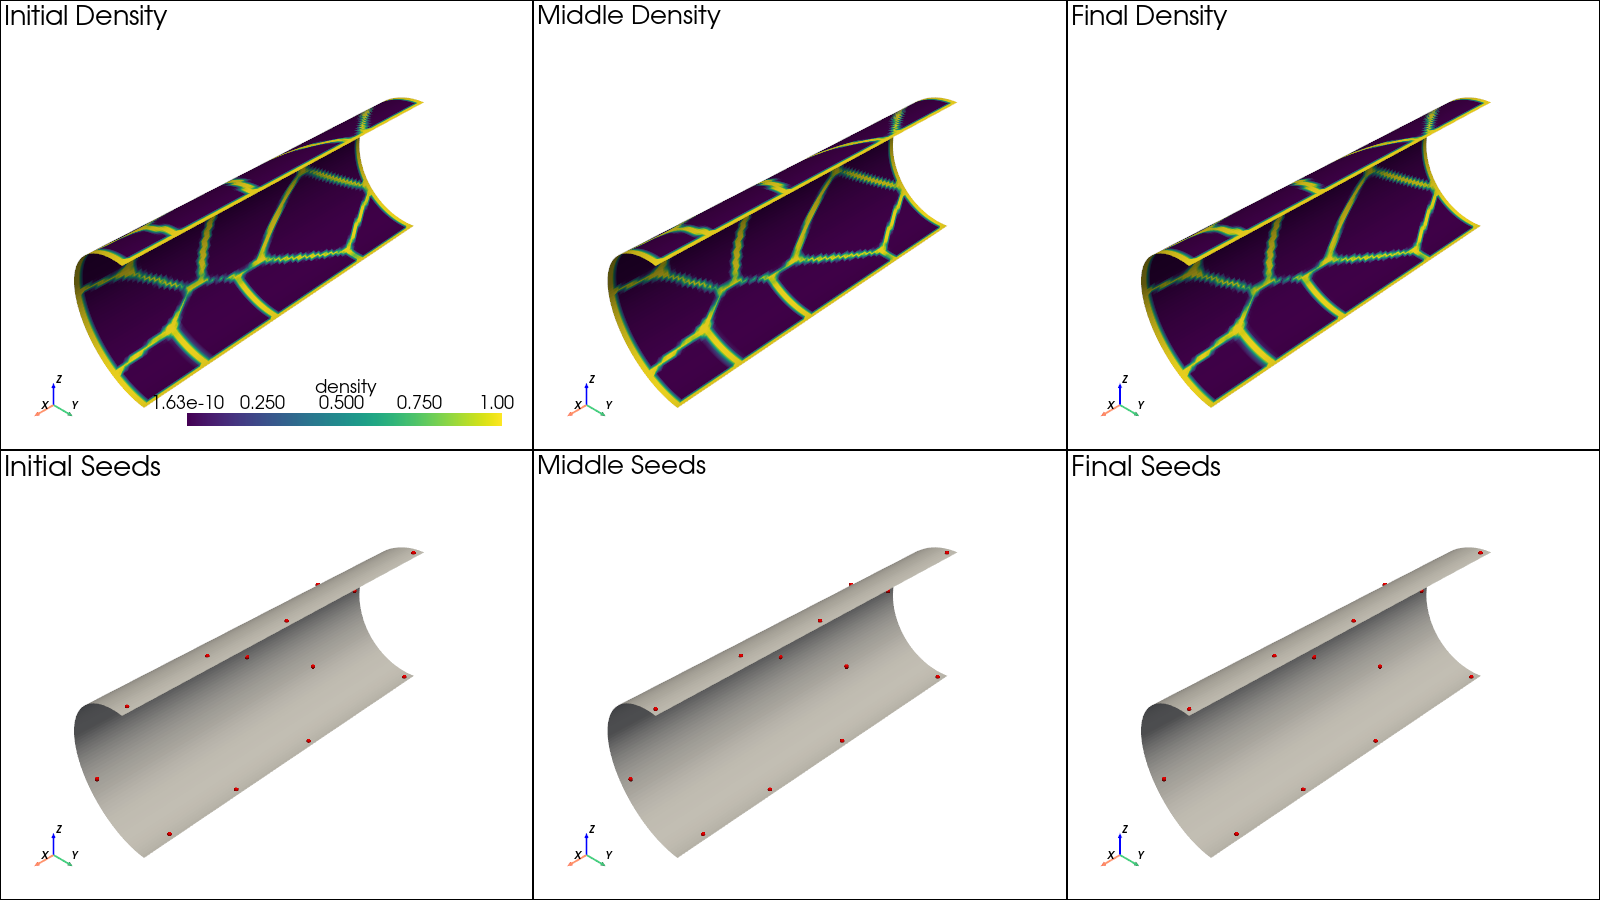

threshold=0.01 (manual) | solid%=28.380%


/home/arash/VoronoiImp-main/Utils/CADVisualizer.py:346: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


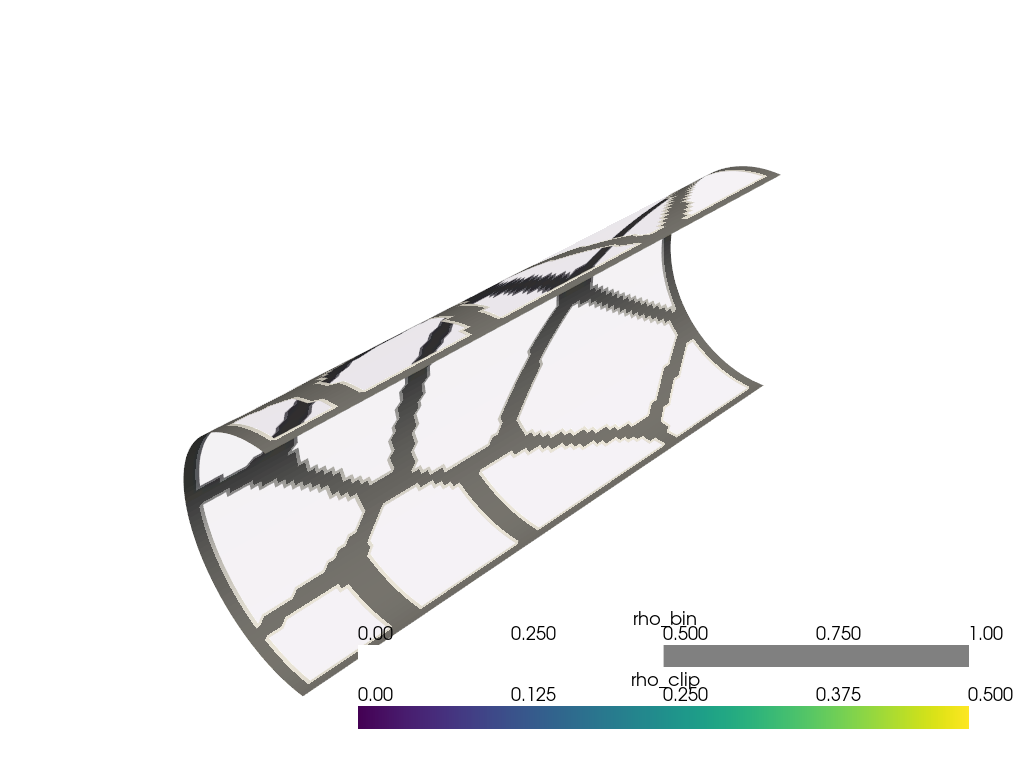

In [3]:
cfg = TrainingConfig(
    seed_number=15,
    use_anisotropy=False,
    target_volfrac=0.2,
    lam_vol=2.0,
    lam_rep=0.5,
    lam_bnd=0.5,
    lam_best_vol=5.0,
    num_steps=10000,
    context_vector_size=8,
    tau=0.02,
    beta=0.05,
    log_every=50,
    early_stop_start=300,
    patience=300,
    min_delta=1e-4,
)

trainer = NN_Trainer(
    generator=generator,
    loss_obj=loss_obj,
    viz=viz,
    decoder_cls=VoronoiDecoder,
    ppnet_cls=PPNet,
    config=cfg,
)

result = trainer.train(
    uv=uv,
    points_xyz=points_xyz,
    face_areas=face_areas,
    faces_ijk=faces_ijk,
    face_id=face_id,
    boundary_idx_ring1=boundary_idx_ring1,
)

trainer.visualize_result_stepwise(result, points_xyz, faces_ijk)
trainer.visualize_result_final(result, points_xyz, faces_ijk, thr=0.01, show_solid=True)

In [10]:

problem = TipCantilever_30_20_20_midLoad()


fem = run_fem_loss.NeuralTOMOFEM(problem, device=device, isotropic=False)

nelx = problem.mesh["nelx"]
nely = problem.mesh["nely"]
nelz = problem.mesh["nelz"]
nele = nelx * nely * nelz

density = torch.full((nele,), 0.5, device=fem.device)
fiber_dir = torch.randn(nele, 3, device=fem.device)
#print(fiber_dir)
stress, comp = fem(density, fiber_dir, penal=3)

print("stress:", float(stress))
print("comp  :", float(comp))

stress: 3.631395202319254e-06
comp  : 3305037103104.0
